In [1]:
import pandas as pd
import numpy as np
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm

In [2]:
import sys
data_path = '../data/github/'
sys.path.append('../codes/')
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py

In [3]:
# deaths_37_array = np.array(deaths_37_list).T
# np.savetxt('deaths_37_phase2.csv', deaths_37_array, delimiter=',')
deaths_37_array = np.loadtxt('deaths_37_phase2_v2.csv',delimiter=',')

In [4]:
deaths_37_array.shape

(66, 4)

In [4]:
CM_06 = np.loadtxt('CM_37_normalised.csv', delimiter=',')
delay_init = (14, 2)
delay_dist_init = delay_dist(delay_init[0],delay_init[1],21)
####
n_races = 4
n_states = 7

In [5]:
n_wk_in_wd = 4
T = (54+2)*7 #28*8+14+14 #7*n_wk_window+14 
beta_base_37 = np.zeros((T,4))
# beta_base_06 = prior_beta_06[:28,:]
beta_base_37[:,:] = 1
####
IFR_37_daily_wd = np.zeros((T,4))
IFR_37_daily_wd_phase1 = np.loadtxt('my_ifr_ts-v4_37.csv')
end_idx = IFR_37_daily_wd_phase1.shape[0] -14
IFR_37_daily_wd[:end_idx,:] = IFR_37_daily_wd_phase1[:end_idx,:]
IFR_37_daily_wd[end_idx:] = IFR_37_daily_wd_phase1[end_idx-1]

In [6]:
M_eta_37 = np.loadtxt('M_eta_37.csv')
IFR_37_daily_wd.shape == M_eta_37.shape

True

In [8]:
11000 - 5*300

9500

In [7]:
# np.save('M_trace', M_trace)
M_trace = np.load('M_trace_37_v2.npy')
n_mcmc = M_trace.shape[0]
burn_in = 9000
n_windows = 9
step = 10
thin = int((n_mcmc - burn_in)/step)
# thin = 200
M_death_wk = np.zeros((thin,54,4))
M_State = np.zeros((thin,T,7,4))
M_trace_steady = M_trace[[-(n_mcmc - burn_in)+step*k1+1 for k1 in range(thin)]]
M_betas = np.zeros((thin,4))

In [8]:
# humudity_raw=pd.read_csv(data_path+'NY_humudity_1.csv')
# humudity=humudity_raw.values[:366] #
# R_max=2.5
# R_min=0.1
# D = 3.
# hum=(np.exp(-180*humudity+np.log(R_max-R_min))+R_min)/D
# hum_factor=hum/np.mean(hum)
# hum_ravel = hum_factor.ravel()
# hum_two_year = np.tile(hum_ravel,2)
# ### projection starts from 
# ### November 28, 2020 is the 332th day of the year
# print(hum_two_year[332])
# hum_scaled = hum_two_year/hum_two_year[332]

# humudity_raw = pd.read_csv(data_path+'NY_humudity_1.csv')
# hum_ravel = humudity_raw['humudity'].values
abshum = pd.read_csv('../data/abshumidity.csv')
# selected_columns = abshum.columns[abshum.columns.str.contains('NC')]
# nc_df = abshum[selected_columns]
# nc_df_mean = nc_df.mean(axis=1)
# hum_ravel = nc_df_mean.values
hum_ravel = abshum.mean(axis=1).values
hum_two_year = np.tile(hum_ravel,2)
R_max = 1.2
R_min = 1
D = 5
hum = (np.exp(-180*hum_two_year+np.log(R_max-R_min))+R_min)/D
hum_factor = hum/np.mean(hum)
humidity = hum_factor[319:319+154]
# humidity = humidity/humidity[0]
# humidity_previous = hum_factor[81:319]
# hum_scaled = humudity/humudity[0]

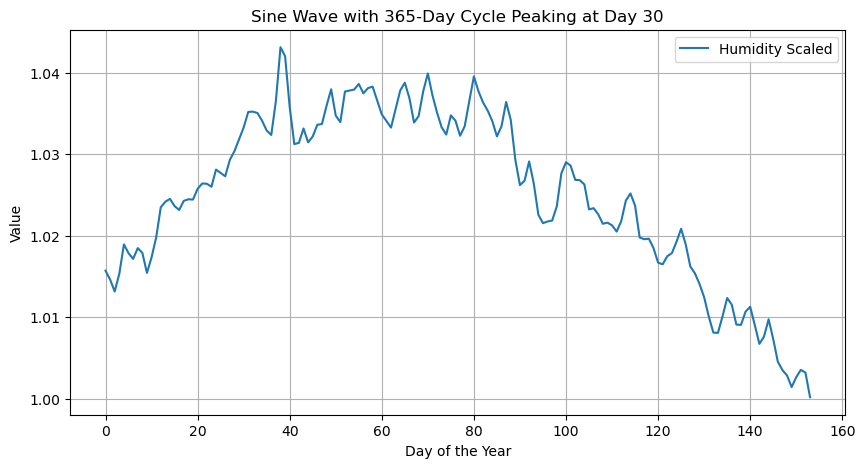

In [11]:
plt.figure(figsize=(10, 5))
# plt.plot(days+332, seasonal, label='Sine Wave')
plt.plot(range(len(humidity)), humidity, label='Humidity Scaled')
# plt.axvline(252)
plt.title('Sine Wave with 365-Day Cycle Peaking at Day 30')
plt.xlabel('Day of the Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
NPI_37 = pd.read_csv('stringency_wk_nc.csv')
print (len(NPI_37))

51


In [10]:
dates_weekly = pd.date_range(start='2020-03-01', periods=51, freq='W-SAT')
dates_daily = pd.date_range(start=dates_weekly[0] - pd.Timedelta(days=6), end=dates_weekly[-1], freq='D')

In [11]:
daily_df = pd.DataFrame(0.00, index=dates_daily, columns=range(1))
# Distribute weekly values backward
for i, date in enumerate(dates_weekly[1:]):
    # Find the start date of the week
    week_start = date - pd.Timedelta(days=6)
    # Assign and distribute weekly values to each day of the corresponding week
    # up = NPI_06['StringencyIndex_WeightedAverage'][i+1]
    low = NPI_37['StringencyIndex_WeightedAverage'][i]
    # step = (up - low)/7
    # weekly_value = np.array([[low + step * j] for j in range(7)])
    weekly_value = np.array([[low]*7])
    daily_df.loc[week_start:date,0] =  weekly_value
# Calculate the 7-day rolling average for smoothing, aligning the window to end on the 'start_date'
smoothed_daily_df = daily_df.rolling(window=7, min_periods=1).mean()

[80.56] 73.15


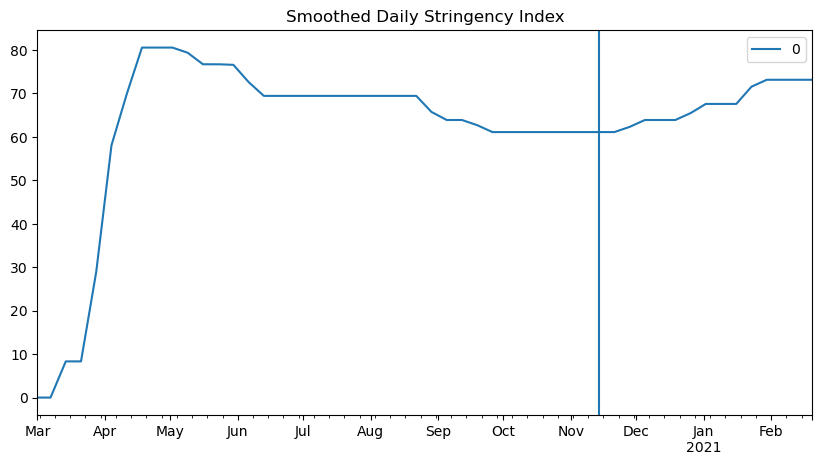

In [15]:
smoothed_daily_df.plot(figsize=(10, 5), title='Smoothed Daily Stringency Index')
plt.axvline('2020-11-14')
print(max(smoothed_daily_df.values),min(smoothed_daily_df.iloc[-1]))

In [12]:
selected_daily = smoothed_daily_df[smoothed_daily_df.index > '2020-11-13'][0].values
f_npi = np.zeros(T-end_idx)
f_npi[:len(selected_daily)] = selected_daily
f_npi[len(selected_daily):] = selected_daily[-1]
prediton_period = T - end_idx

Text(0.5, 0, 'npi_factor')

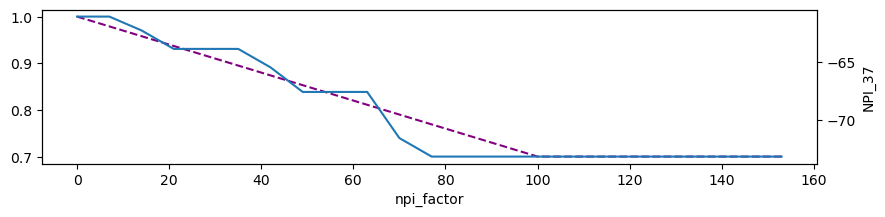

In [13]:
my_npi_062 = -f_npi/14 + (1-(-f_npi/14)[0])
# my_npi_06 = f_npi
my_npi_06 = np.zeros_like(f_npi)
# step1 = 0.2/(40)
# decrease1 = [1-step1*i for i in range(40)]
step2 = 0.3/(100)
decrease2 = [1-step2*i for i in range(100)]
# my_npi_06[:21] = 1
# my_npi_06[:40] = decrease1
my_npi_06[:100] = decrease2
my_npi_06[100:] = 0.7
# my_npi_06[:60] = np.array([1-decrease*i for i in range(60)])
# my_npi_06[:42] = 1
# my_npi_06[40:68] = 0.8
# my_npi_06[68:100] = 0.5
# my_npi_06[100:] = 0.8
fig, ax1 = plt.subplots(figsize=(10,2))
# ax1.plot(my_npi_06[:prediton_period],color = 'red')
ax1.plot(my_npi_06[:prediton_period],color = 'purple',ls='dashed')

ax2 = ax1.twinx()
ax2.plot(-f_npi[:prediton_period])
# plt.plot(f_npi)
ax2.set_ylabel('NPI_37')
ax1.set_xlabel('npi_factor')

In [18]:
mobility_fact = np.zeros_like(f_npi)
step_d = 0.3/90
decrease_m = [1. - step_d*j for j in range(90)]

mobility_fact[:90] = 1. #decrease_m

step_m = 1/(len(f_npi)-90)
increase_m = [1.+step_m*j for j in range(len(f_npi)-90)]
mobility_fact[90:] = increase_m

Text(0, 0.5, 'mobility_factor')

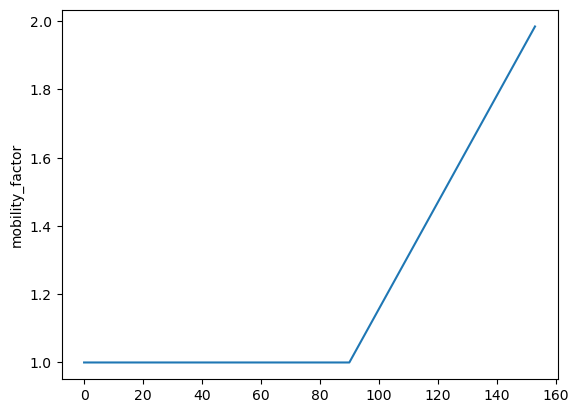

In [19]:
plt.plot(mobility_fact)
plt.ylabel('mobility_factor')

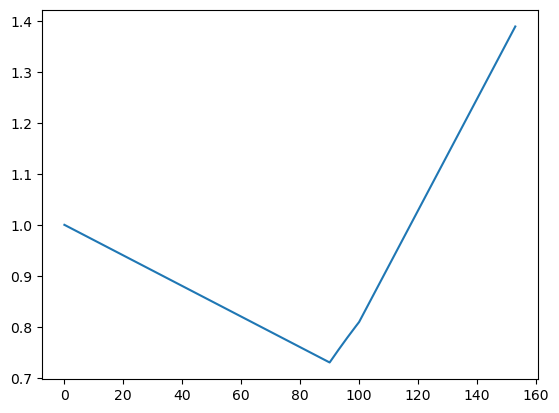

In [20]:
plt.plot(my_npi_06*mobility_fact)

In [14]:
# M_trace_steady = M_trace[[4000 + step*k1+1 for k1 in range(thin)]]
for s_i in range(thin):
    seed_post_i = M_trace_steady[s_i,0,:]        
    State = np.zeros((T, n_states, n_races))
    statestart = getStart(seed=seed_post_i, factor=3, N_all=global_N_37)
    State[0] = statestart
    state_check = State
    factor_post_i = M_trace_steady[s_i,1:,:]
    beta_t_check = np.zeros((T,4))
    beta_t_check_phase1 = np.repeat(factor_post_i,28, axis=0)
    beta_t_check[:end_idx] = beta_t_check_phase1[:end_idx,:]
    beta_t_check[end_idx:] = beta_t_check_phase1[end_idx-1]
    beta_t_check[end_idx:] = beta_t_check[end_idx:]*my_npi_06[:prediton_period,np.newaxis]*humidity[:prediton_period,np.newaxis]
    # **(mobility_fact[:prediton_period,np.newaxis])*my_npi_06[:prediton_period,np.newaxis]
    _, death_wk, state_alltime = get_wk_death(state_check,beta_t_check,M_eta_37,IFR_37_daily_wd, delay_dist_init,T,0.95,37)
    M_death_wk[s_i,:,:] = death_wk
    M_State[s_i,:,:,:] = state_alltime[:,:,:]
    M_betas[s_i,:] = factor_post_i[-1,:]

asian
white
black
other


Text(0.5, 0, 'Weeks')

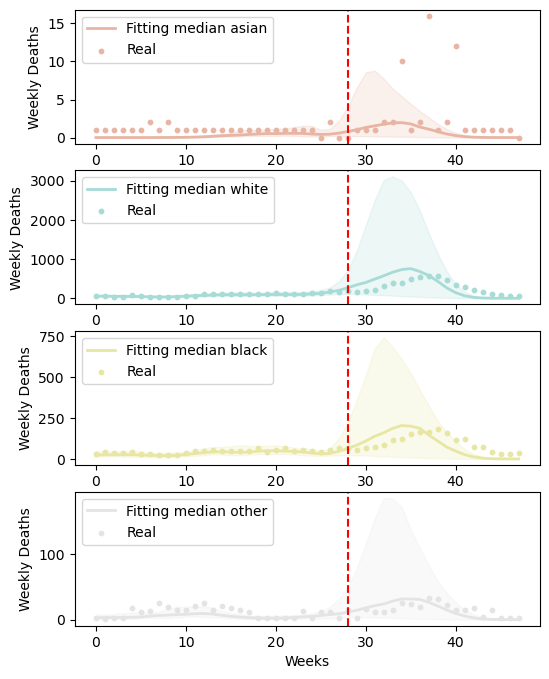

In [45]:
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
for r_idx in range(4):
    r = race_list_37[r_idx]
    print(r)
    ax = axs[r_idx]
    death_r = np.median(M_death_wk[:,6:,r_idx],axis=0)
    death_r_l = np.quantile(M_death_wk[:,6:,r_idx],0.025,axis=0)
    death_r_u = np.quantile(M_death_wk[:,6:,r_idx],0.975,axis=0)
    
    ax.plot(range(54-6), death_r, label=f"Fitting median {r}",c = custom_colors[r], lw=2)
    ax.fill_between(range(54-6), death_r_l, death_r_u, alpha=0.2, color=custom_colors[r])
    ax.scatter(range(54-6), deaths_37_array[11+6:11+54,r_idx], c=custom_colors[r], s=10, label="Real")
    # plt.plot(death_wk[:,r_idx], 'o', label=f"Simulated: {r}", c=custom_colors[r])
    ax.set_ylabel('Weekly Deaths')
    ax.legend()
    ax.axvline(28, color='red', linestyle='--')
plt.xlabel('Weeks')

### out

In [54]:
M_death_wk.shape
dates_weekly_out = pd.date_range(start='2020-11-15', periods=20, freq='W-SUN').strftime('%Y-%m-%d')
column_names = ['origin_date', 'scenario_id', 'target','horizon','location','race_ethnicity','output_type','output_type_id','value','run_grouping','stochastic_run']
df_all_out = pd.DataFrame(columns=column_names)

In [55]:
M_death_out = np.zeros((200,20,5)) ## add overall
M_death_out[:,:,:4] = M_death_wk[:,-20:,:]
M_death_out[:,:,4] = np.sum(M_death_wk[:,-20:,:],axis=2)

In [56]:
for r_idx in range(5):
    if r_idx < 4:
        r = race_list_37[r_idx]
    else:
        r = 'overall'
    for run_i in range(200):
        m_death_wk_i_r = M_death_out[run_i,:,r_idx]
        df_i_r = pd.DataFrame(m_death_wk_i_r, columns=['value'])
        df_i_r['origin_date'] = '2020-11-15'
        df_i_r['scenario_id'] = 'A-2020-05-01'
        df_i_r['target'] = 'inc death'
        df_i_r['location'] = '37'
        df_i_r['stochastic_run'] = 1 ### If each model run is not stochastic, the column will be set to a unique identifier: 1 for all rows
        df_i_r['horizon'] = np.arange(1,20+1)
        df_i_r['race_ethnicity'] = r
        df_i_r['output_type'] = 'sample'
        df_i_r['output_type_id'] = 'NA'
        df_i_r['run_grouping'] = run_i+1
        df_i_r['stochastic_run'] = 1
        df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)

/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_89330/684247473.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)


In [57]:
# M_State
new_case = np.zeros((200,56*7,n_races))
M_inf_wk = np.zeros_like(M_death_wk)
new_case[:,0,:] = M_State[:,0,1,:]/parameters['Z'] + M_State[:,0,5,:]/parameters['Z']
shift_t = len(delay_dist_init)
for i in range(200):
    new_case_t = new_case[i]
    for t in range(1, 56*7):
        deltacase = M_State[i,t,1,:]/parameters['Z'] + M_State[i,t,5,:]/parameters['Z']
        deltacase = deltacase.reshape(1, n_races)
        prob_case = delay_dist_init.dot(deltacase) ## delay to observe
        new_case_t[t:min(t+shift_t,56*7)] += prob_case[:min(56*7-t,shift_t)]
        new_case[i] = new_case_t
    M_inf_wk[i] = Reshape_WK(new_case[i],21,54,5)

In [58]:
M_inf_out = np.zeros((200,20,5)) ## add overall
M_inf_out[:,:,:4] = M_inf_wk[:,-20:,:]
M_inf_out[:,:,4] = np.sum(M_inf_wk[:,-20:,:],axis=2)

In [59]:
for r_idx in range(5):
    if r_idx < 4:
        r = race_list_37[r_idx]
    else:
        r = 'overall'
    for run_i in range(200):
        m_inf_wk_i_r = M_inf_out[run_i,:,r_idx]
        df_i_r = pd.DataFrame(m_inf_wk_i_r, columns=['value'])
        df_i_r['origin_date'] = '2020-11-15'
        df_i_r['scenario_id'] = 'A-2020-05-01'
        df_i_r['target'] = 'inc inf'
        df_i_r['location'] = '37'
        df_i_r['stochastic_run'] = 1 ### If each model run is not stochastic, the column will be set to a unique identifier: 1 for all rows
        df_i_r['horizon'] = np.arange(1,20+1)
        df_i_r['race_ethnicity'] = r
        df_i_r['output_type'] = 'sample'
        df_i_r['output_type_id'] = 'NA'
        df_i_r['run_grouping'] = run_i+1
        df_i_r['stochastic_run'] = 1
        df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)

In [60]:
df_all_out.to_csv('output_37_v2.csv',index=False)

In [17]:
from scipy.stats import gaussian_kde

In [15]:
contact_p = np.array([7.62,	7.09,	8.29,	8.94])

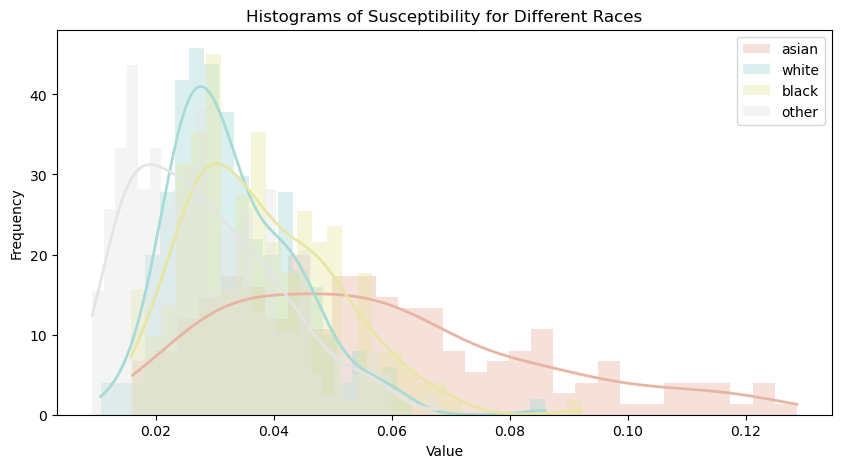

In [18]:
plt.figure(figsize=(10, 5))
for r_idx in range(4):
    r = race_list_37[r_idx]
    inf_r_0 = M_betas[:,r_idx]
    sus_r = inf_r_0/contact_p[r_idx]
    plt.hist(sus_r, bins= 30, alpha=0.4, label=f'{r}', color=custom_colors[r],density=True)
    kde = gaussian_kde(sus_r)
    x_vals = np.linspace(min(sus_r), max(sus_r), 1000)
    kde_vals = kde(x_vals)
    # Plot the KDE
    plt.plot(x_vals, kde_vals, color=custom_colors[r],lw=2)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histograms of Susceptibility for Different Races')
plt.legend(loc='upper right')